In [3]:
import sys, os
sys.path.append('..')
os.environ['JAX_PLATFORMS'] = 'cpu'

import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

from utils import makefolder, depths, reduce_list_half_preserve_extremes

rcpsize = 14
plt.rcParams['xtick.labelsize'] = rcpsize
plt.rcParams['ytick.labelsize'] = rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': False})

colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

models = ['deepseek', 'qwen7b', 'gemma12b']
_models = ['DeepSeek-V3', 'Qwen2-7B', 'Gemma3-12B']
markers = ['o', 's', '^']

curve_specs = [
    ('syntax twins', 0, None),
    ('syntax-ablated syntax twins', 1, 'projection'),
    ('random-ablated syntax twins', -1, 'projection'),
]

panel_specs = [
    ('a)', 'Concatenation', 0, 6),
    ('b)', 'Average', 1, 6),
    ('c)', 'Last token', 0, 1),
]


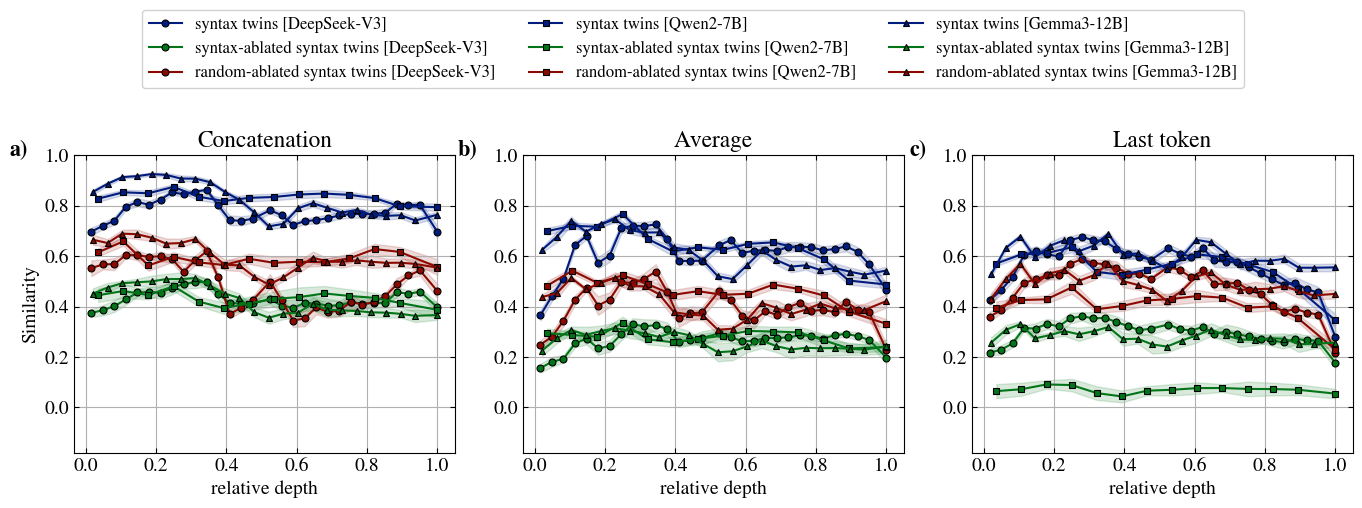

In [4]:
precision = 32
ratio_jackknife = 0.5
global_centering = 0
batch_shuffle = 0
centers_var = 'syn'
n_files = 21
Nbits = 0
data_var = 'syn'
match_var = 'matching'
zero_activations = 0
min_token_length = 6

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8), sharey=True)

legend_handles = []
legend_labels = []

for panel_id, (panel_label, title, avg_tokens, n_tokens) in enumerate(panel_specs):
    for model_id, modelA in enumerate(models):
        modelB = modelA
        layers_A = list(range(1, depths[modelA] + 1))
        layers = np.array(reduce_list_half_preserve_extremes(layers_A), dtype=float)
        layers /= depths[modelB]

        output_folder0 = makefolder(
            base='../results/',
            global_centering=global_centering,
            spaces='AB',
            similarity_fn='normalized_L2_distance',
            precision=precision,
            language='english',
            data_var=data_var,
            modelA=modelA,
            modelB=modelB,
            match_var=match_var,
            n_files=n_files,
            min_token_length=min_token_length,
        )

        for curve_id, (label, center_flag, removal_method) in enumerate(curve_specs):
            II_folder = makefolder(
                base=output_folder0,
                centers=centers_var,
                Nbits=Nbits,
                n_tokens=n_tokens,
                avg_tokens=avg_tokens,
                batch_shuffle=batch_shuffle,
                zero_activations=zero_activations,
                center_A_flag=center_flag,
                center_B_flag=center_flag,
                removal_method=removal_method,
            )

            inf_imb = 1 - np.load(os.path.join(II_folder, f'II_{ratio_jackknife:.2f}.npy')).mean(axis=0)
            std = np.load(os.path.join(II_folder, f'II_jack_std_{ratio_jackknife:.2f}.npy')).mean(axis=0)

            _label = f'{label} [{_models[model_id]}]'
            line = ax[panel_id].plot(
                layers,
                inf_imb.diagonal(),
                label=_label,
                color=colors[curve_id],
                marker=markers[model_id],
                markersize=5,
                markerfacecolor=colors[curve_id],
                markeredgecolor='black',
                markeredgewidth=0.8,
            )[0]
            ax[panel_id].fill_between(
                layers,
                inf_imb.diagonal() - std.diagonal(),
                inf_imb.diagonal() + std.diagonal(),
                alpha=0.15,
                color=colors[curve_id],
            )

            if panel_id == 0:
                legend_handles.append(line)
                legend_labels.append(_label)

    ax[panel_id].set_title(title)
    ax[panel_id].set_xlabel('relative depth')
    ax[panel_id].grid()
    ax[panel_id].tick_params(
        top=True,
        bottom=True,
        left=True,
        right=True,
        labeltop=False,
        labelbottom=True,
        labelleft=True,
        labelright=False,
        direction='in',
    )
    ax[panel_id].set_ylim(-0.18, 1.0)
    ax[panel_id].text(
        -0.12,
        1.05,
        panel_label,
        transform=ax[panel_id].transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right',
    )

ax[0].set_ylabel('Similarity')

fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=3,
    framealpha=0.9,
    fontsize=12,
)
fig.subplots_adjust(top=0.73, wspace=0.18)

figs_folder = '../results/figs/syntax_similarity'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(
    os.path.join(figs_folder, 'all_models_syntax_similarity_concat_avg_last_token.pdf'),
    bbox_inches='tight',
)
plt.show()
